# Phase 6: Clinical Recurrence Risk (TCGA-THCA)
Score the Phase 4 RAI-resistance signature on **real** TCGA thyroid-cancer patients (UCSC Xena public hub) and test whether it predicts progression-free interval (PFI), the recommended recurrence endpoint for THCA.

### Cell 1: Download TCGA-THCA Data (first run only)

In [1]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

PROCESSED_DIR = os.path.join(os.getcwd(), "processed_data")
TCGA_DIR = os.path.join(os.getcwd(), "data", "tcga")
os.makedirs(TCGA_DIR, exist_ok=True)

XENA = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/"
files = {
    "THCA_HiSeqV2.gz":         "TCGA.THCA.sampleMap%2FHiSeqV2.gz",       # log2(RSEM norm count + 1)
    "THCA_survival.txt":       "survival%2FTHCA_survival.txt",            # OS / DSS / DFI / PFI
    "THCA_clinicalMatrix.txt": "TCGA.THCA.sampleMap%2FTHCA_clinicalMatrix",
}
for local, remote in files.items():
    path = os.path.join(TCGA_DIR, local)
    if not os.path.exists(path):
        print("Downloading", local)
        urllib.request.urlretrieve(XENA + remote, path)
print("TCGA files ready in", TCGA_DIR)

TCGA files ready in C:\Users\omar_\OneDrive\Pictures\Documents\Project codes\thyroid_scRNA\data\tcga


### Cell 2: Score the RAI Signature on Primary Tumours

In [2]:
expr = pd.read_csv(os.path.join(TCGA_DIR, "THCA_HiSeqV2.gz"), sep="\t", index_col=0)
expr = expr.loc[:, expr.columns.str[13:15] == "01"]          # primary tumour samples only

signature = pd.read_csv(os.path.join(PROCESSED_DIR, "rai_signature_genes.csv"))["gene"].tolist()
present = [g for g in signature if g in expr.index]
sig_expr = expr.loc[present]
sig_expr = sig_expr[sig_expr.std(axis=1) > 0]
z = sig_expr.sub(sig_expr.mean(axis=1), axis=0).div(sig_expr.std(axis=1), axis=0)
rai_score = z.mean(axis=0).rename("RAI_Score")
print(f"Primary tumours: {expr.shape[1]} | signature genes found in TCGA: {len(sig_expr)}/{len(signature)}")

Primary tumours: 505 | signature genes found in TCGA: 48/50


### Cell 3: Merge with Survival & Clinical Covariates

In [3]:
surv = pd.read_csv(os.path.join(TCGA_DIR, "THCA_survival.txt"), sep="\t", index_col="sample")
clin = pd.read_csv(os.path.join(TCGA_DIR, "THCA_clinicalMatrix.txt"), sep="\t", index_col="sampleID")

stage_map = {"I": 1, "II": 2, "III": 3, "IV": 4}
stage = clin["pathologic_stage"].str.extract(r"Stage (IV|III|II|I)")[0].map(stage_map)

tcga_df = pd.concat([
    rai_score,
    surv["PFI.time"].rename("time_to_recurrence"),
    surv["PFI"].rename("recurrence_event"),
    clin["age_at_initial_pathologic_diagnosis"].rename("age"),
    stage.rename("stage"),
], axis=1, join="inner").dropna()
tcga_df = tcga_df[tcga_df["time_to_recurrence"] > 0]
tcga_df.index.name = "sample"
print(f"Patients in analysis: {len(tcga_df)} | recurrence/progression events: {int(tcga_df['recurrence_event'].sum())}")
tcga_df.head()

Patients in analysis: 502 | recurrence/progression events: 52


,RAI_Score,time_to_recurrence,recurrence_event,age,stage
sample,,,,,
TCGA-DJ-A4V5-01,0.374304,1076,0,55,4.0
TCGA-L6-A4EQ-01,0.164531,1228,0,47,3.0
TCGA-FE-A3PB-01,0.701386,2590,0,33,1.0
TCGA-E8-A2EA-01,0.765829,1085,0,52,1.0
TCGA-ET-A3DS-01,-1.486552,2033,0,33,1.0


### Cell 4: Multivariable Cox Model (adjusted for age & stage)

In [4]:
cph = CoxPHFitter()
cph.fit(tcga_df[["time_to_recurrence", "recurrence_event", "RAI_Score", "age", "stage"]],
        duration_col="time_to_recurrence", event_col="recurrence_event")
cph.print_summary(decimals=3)
print(f"Concordance index: {cph.concordance_index_:.3f}")

<lifelines.CoxPHFitter: fitted with 502 total observations, 450 right-censored observations>
             duration col = 'time_to_recurrence'
                event col = 'recurrence_event'
      baseline estimation = breslow
   number of observations = 502
number of events observed = 52
   partial log-likelihood = -294.140
         time fit was run = 2026-09-27 16:50:22 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
RAI_Score 0.003     1.003     0.223          -0.435           0.441               0.648               1.554
age       0.000     1.000     0.012          -0.022           0.023               0.978               1.023
stage     0.451     1.570     0.154           0.150           0.753               1.161               2.123

           cmp to     z     p  -log2(p)
covariate                              
RAI_Score   0.000 0.014 0.989     0.016
age         0.000 0.036 0.971     0.042
stage       0.000 2.932 0.003     8.215
---
Concordance = 0.617
Partial AIC = 594.280
log-likelihood ratio test = 14.414 on 3 df
-log2(p) of ll-ratio test = 8.707

Concordance index: 0.617


### Cell 5: Kaplan-Meier Curves (median split of RAI Score)

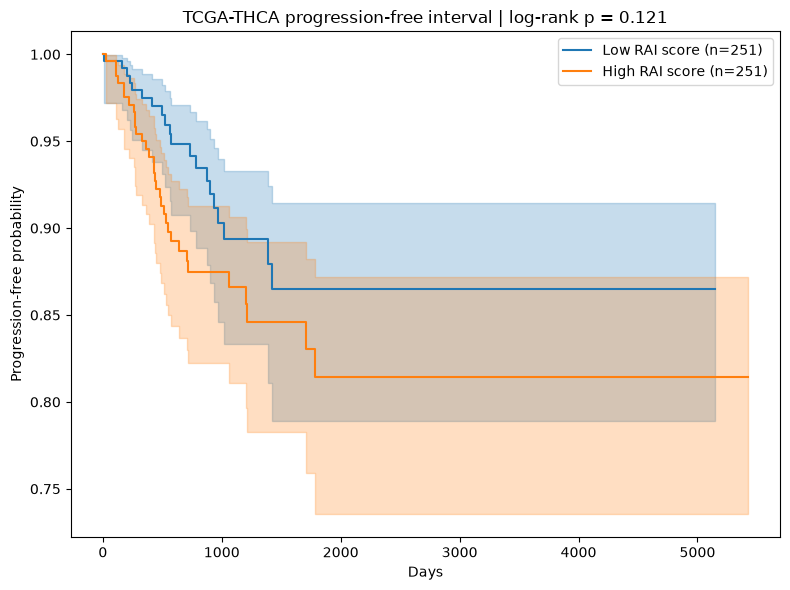

In [5]:
tcga_df["risk"] = pd.qcut(tcga_df["RAI_Score"], 2, labels=["Low", "High"])
low, high = tcga_df[tcga_df["risk"] == "Low"], tcga_df[tcga_df["risk"] == "High"]
lr_test = logrank_test(low["time_to_recurrence"], high["time_to_recurrence"],
                       low["recurrence_event"], high["recurrence_event"])

fig, ax = plt.subplots(figsize=(8, 6))
for name, grp in [("Low", low), ("High", high)]:
    KaplanMeierFitter().fit(grp["time_to_recurrence"], grp["recurrence_event"],
                            label=f"{name} RAI score (n={len(grp)})").plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel("Days")
ax.set_ylabel("Progression-free probability")
ax.set_title(f"TCGA-THCA progression-free interval | log-rank p = {lr_test.p_value:.3g}")
plt.tight_layout()
plt.show()

### Cell 6: Save Results

In [6]:
tcga_df.to_csv(os.path.join(PROCESSED_DIR, "final_recurrence_risk.csv"))
cph.summary.to_csv(os.path.join(PROCESSED_DIR, "cox_summary.csv"))
print("Saved final_recurrence_risk.csv and cox_summary.csv")
print("Phase 6 Complete!")

Saved final_recurrence_risk.csv and cox_summary.csv
Phase 6 Complete!
